In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

<Figure size 640x480 with 0 Axes>

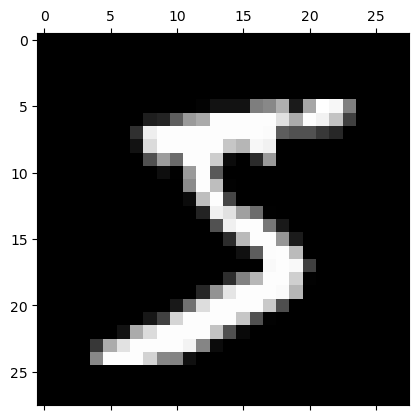

In [3]:
plt.gray()
plt.matshow(x_train[0])

In [4]:
y_train[0]

5

In [5]:
x_train = x_train/255 # without scaling the model perform worse
x_test = x_test/255

In [6]:
x_train_flattened = x_train.reshape(len(x_train),28*28)
x_test_flattened = x_test.reshape(len(x_test),28*28)

In [7]:
x_train_flattened.shape

(60000, 784)

In [22]:
model = keras.Sequential([ # Sequential = stack of layers
    keras.layers.Dense(10, input_shape=(784,),activation='sigmoid')# every node in this layer is connected to every other node in the next layer
]) # simple NN with only 2 layers, input layer and an output layer. inputs = 784, 10 neurons, outputs = 10(each neuron produce one output)

tb_callback = tf.keras.callbacks.TensorBoard(log_dir='logs/SGD', histogram_freq=1)

model.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(x_train_flattened, y_train, epochs=5, callbacks=[tb_callback]) # While training tensorflow give all info about epoch to tb_callback

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7135 - loss: 1.1370
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8773 - loss: 0.4772
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8894 - loss: 0.4121
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8937 - loss: 0.3850
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9005 - loss: 0.3628


To launch tensorboard in cmd prompt 
tensorboard --logdir logs/

To launch tensorboard within jupyter notebook
%load_ext tensorboard
%tensorboard --logdir logs/fit